<a href="https://colab.research.google.com/github/MayankJ03/Skin-cancer-segmentation-/blob/main/skin_cancer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob as gb
from PIL import Image
import os
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Conv2DTranspose, add
from tensorflow.keras import Model
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p /root/.kaggle

In [ ]:
import json

# Save the credentials to kaggle.json
kaggle_dict = {"username":"mayankj007","key":"adc42dbe94dbd055f032a97f62d350e6"}
with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(kaggle_dict, file)

# Set proper permissions
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download -d surajghuwalewala/ham1000-segmentation-and-classification

Dataset URL: https://www.kaggle.com/datasets/surajghuwalewala/ham1000-segmentation-and-classification
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)


In [ ]:
!unzip ham1000-segmentation-and-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: masks/ISIC_0029321_segmentation.png  
  inflating: masks/ISIC_0029322_segmentation.png  
  inflating: masks/ISIC_0029323_segmentation.png  
  inflating: masks/ISIC_0029324_segmentation.png  
  inflating: masks/ISIC_0029325_segmentation.png  
  inflating: masks/ISIC_0029326_segmentation.png  
  inflating: masks/ISIC_0029327_segmentation.png  
  inflating: masks/ISIC_0029328_segmentation.png  
  inflating: masks/ISIC_0029329_segmentation.png  
  inflating: masks/ISIC_0029330_segmentation.png  
  inflating: masks/ISIC_0029331_segmentation.png  
  inflating: masks/ISIC_0029332_segmentation.png  
  inflating: masks/ISIC_0029333_segmentation.png  
  inflating: masks/ISIC_0029334_segmentation.png  
  inflating: masks/ISIC_0029335_segmentation.png  
  inflating: masks/ISIC_0029336_segmentation.png  
  inflating: masks/ISIC_0029337_segmentation.png  
  inflating: masks/ISIC_0029338_segmentation.png  
  inflating: masks/ISIC_0029339

In [ ]:
img_dir = "/content/images"
mask_dir = "/content/masks"

img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])
mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith(".png")])

In [ ]:
image_names = [os.path.splitext(f)[0] for f in img_files]    # ('ISIC_0024306', '.jpg')
mask_names = [os.path.splitext(f)[0].replace('_segmentation', '') for f in mask_files]    # ('ISIC_0024306_segmentation', 'png')

missing_masks = [f for f in image_names if f not in mask_names]

if len(missing_masks) == 0:
    print('No missing masks found.')
else:
    print(f"There are {len(missing_masks)} missing masks found:")
    print(missing_masks)

No missing masks found.


In [ ]:
len(img_files), len(mask_files)

(10015, 10015)

In [ ]:
def display_image_and_mask(n=5, seed=None):
    if seed:
        np.random.seed(seed)

    fig, axs = plt.subplots(2, n, figsize=(20, 6))
    for i in range(n):
        idx = np.random.randint(0, len(img_files))
        img_path = os.path.join(img_dir, img_files[idx])
        mask_path = os.path.join(mask_dir, os.path.splitext(img_files[idx])[0] + '_segmentation.png')    # mask_files[idx]

        img = Image.open(img_path)
        mask = Image.open(mask_path)

        axs[0, i].imshow(img)
        axs[0, i].set_title('Image')
        axs[0, i].axis('off')

        axs[1, i].imshow(mask)
        axs[1, i].set_title('Mask')
        axs[1, i].axis('off')
plt.show()

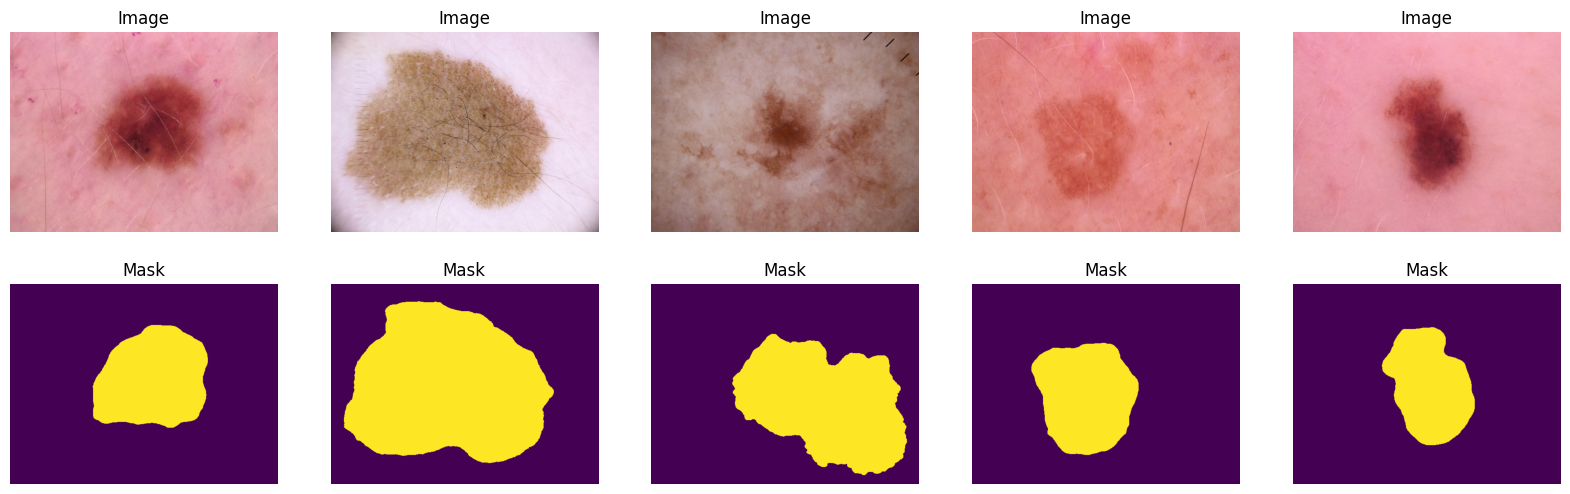

In [ ]:
display_image_and_mask(n=5, seed=42)

In [ ]:
def display_image_with_mask(n=5, seed=None):
    if seed:
        np.random.seed(seed)

    fig, axs = plt.subplots(1, n, figsize=(20, 5))
    for i in range(n):
        idx = np.random.randint(0, len(img_files))
        img_path = os.path.join(img_dir, img_files[idx])
        mask_path = os.path.join(mask_dir, os.path.splitext(img_files[idx])[0] + '_segmentation.png')    # mask_files[idx]

        img_np = np.array(Image.open(img_path))
        mask_np = np.array(Image.open(mask_path))

        axs[i].imshow(img_np)
        axs[i].imshow(mask_np, cmap='Reds', alpha=0.5)
        axs[i].set_title('Image with Mask')
        axs[i].axis('off')

plt.show()

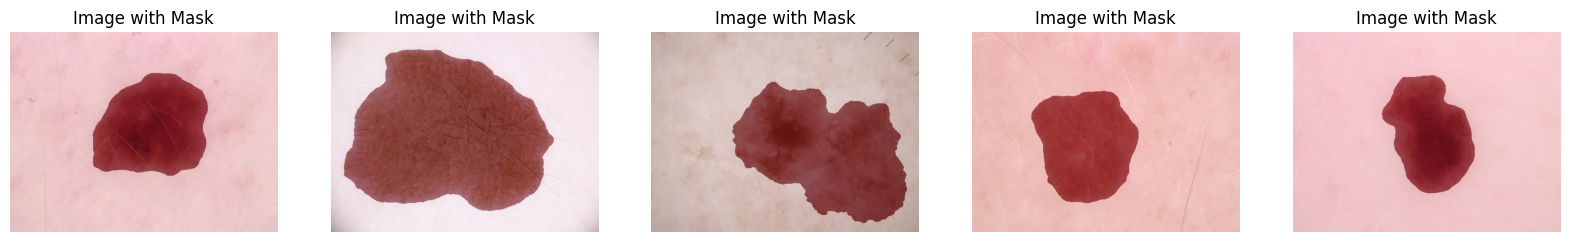

In [ ]:
display_image_with_mask(n=5, seed=42)

In [ ]:
IMG_SIZE = 128  # Reduced from 256 to 128
BATCH_SIZE = 64  # Increased from 32 to 64
BUFFER_SIZE = 1000
AUTOTUNE = tf.data.experimental.AUTOTUNE
# img_dir
# mask_dir

In [ ]:
def img_mask_paths(img_dir, mask_dir):
    img_path = sorted(gb.glob(os.path.join(img_dir, '*.jpg')))
    mask_path = sorted(gb.glob(os.path.join(mask_dir, '*.png')))
    return np.array(img_path), np.array(mask_path)

imgs_path, masks_path = img_mask_paths(img_dir, mask_dir)

In [ ]:
# Limit the total number of samples to speed up training
max_samples = 1000  # Use only a subset of the data
indices = np.random.choice(len(imgs_path), min(max_samples, len(imgs_path)), replace=False)
imgs_path_subset = imgs_path[indices]
masks_path_subset = masks_path[indices]

X_train, X_temp, y_train, y_temp = train_test_split(imgs_path_subset, masks_path_subset, train_size=0.80, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.5, random_state=42)

In [ ]:
print(f"{'Training:':<15}{len(X_train)}")
print(f"{'Validation:':<15}{len(X_val)}")
print(f"{'Testing:':<15}{len(X_test)}")

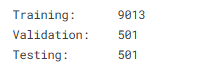

In [ ]:
def map_fn(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_jpeg(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask

In [ ]:
# train_set
train_set = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_set = train_set.map(map_fn, num_parallel_calls=AUTOTUNE)
train_set = train_set.shuffle(buffer_size=BUFFER_SIZE).batch(batch_size=BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

# val_set
val_set = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_set = val_set.map(map_fn, num_parallel_calls=AUTOTUNE)
val_set = val_set.shuffle(buffer_size=BUFFER_SIZE).batch(batch_size=BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

# test_set
test_set = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_set = test_set.map(map_fn, num_parallel_calls=AUTOTUNE)
test_set = test_set.shuffle(buffer_size=BUFFER_SIZE).batch(batch_size=BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Simplified U-Net Model
def UNET():
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = Conv2D(16, 3, strides=1, padding='same')(inputs)  # Reduced filters from 32 to 16
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    skip_connections = []

    # Encoder - Reduced filter sizes
    for filters in [32, 64, 128, 256]:  # Reduced from [64, 128, 256, 512]
        x = Conv2D(filters, 3, strides=1, padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)

        x = Conv2D(filters, 3, strides=1, padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        skip_connections.append(x)
        x = MaxPooling2D(2, strides=2, padding='same')(x)

    # Bottleneck - Reduced filters from 1024 to 512
    x = Conv2D(512, 3, strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(512, 3, strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Decoder - Reduced filter sizes
    for filters in [256, 128, 64, 32]:  # Reduced from [512, 256, 128, 64]
        x = Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
        skip_connection = skip_connections.pop()
        x = add([x, skip_connection])

        x = Conv2D(filters, 3, strides=1, padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)

    outputs = Conv2D(1, 1, strides=1, activation='sigmoid')(x)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

In [ ]:
model = UNET()

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      4,640 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 6,207,009 (23.68 MB)

 Trainable params: 6,202,049 (23.66 MB)

 Non-trainable params: 4,960 (19.38 KB)

In [ ]:
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

In [ ]:
model.compile(optimizer=Adam(0.001),  # Increased from 0.0002 to speed up training
              loss=BinaryCrossentropy(),
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), dice_coefficient])

In [ ]:
checkpoint_cb = ModelCheckpoint('best_weights.weights.h5',
                                monitor='val_loss',
                                verbose=1,
                                save_best_only=True,
                                save_weights_only=True)

reduce_lr_cb = ReduceLROnPlateau(monitor='val_loss',
                                 factor=0.2,
                                 patience=2,
                                 verbose=1)

# Added early stopping to avoid unnecessary training
early_stopping_cb = EarlyStopping(monitor='val_loss',
                                  patience=3,
                                  verbose=1,
                                  restore_best_weights=True)

In [ ]:
# Enable mixed precision for faster training (updated API)
try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled")
except:
    print("Mixed precision not available, continuing with default precision")

# Removed workers and multiprocessing parameters
history = model.fit(
    train_set,
    epochs=10,
    validation_data=val_set,
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stopping_cb]
)

Mixed precision enabled
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24s/step - accuracy: 0.7771 - dice_coefficient: 0.5210 - loss: 0.4699 - precision: 0.6000 - recall: 0.6459 
Epoch 1: val_loss improved from inf to 0.68638, saving model to best_weights.weights.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 346s 24s/step - accuracy: 0.7822 - dice_coefficient: 0.5275 - loss: 0.4626 - precision: 0.6094 - recall: 0.6517 - val_accuracy: 0.7173 - val_dice_coefficient: 0.5296 - val_loss: 0.6864 - val_precision: 0.5207 - val_recall: 0.7923 - learning_rate: 0.0010
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - accuracy: 0.9210 - dice_coefficient: 0.7276 - loss: 0.2287 - precision: 0.8798 - recall: 0.8268 
Epoch 2: val_loss did not improve from 0.68638
13/13 ━━━━━━━━━━━━━━━━━━━━ 316s 24s/step - accuracy: 0.9212 - dice_coefficient: 0.7289 - loss: 0.2280 - precision: 0.8810 - recall: 0.8270 - val_accuracy: 0.7121 - val_dice_coefficient: 0.5923 - val_loss: 1.8113 - val_precision: 0.5150 - val_recall: 0.7923 - learning_rate: 0.0010
Epoch 3/10
13/13

In [ ]:
# Download the model form Google Drive link

!pip install -q gdown
import gdown

# Link of the model file: https://drive.google.com/file/d/1-2AmTeb7WBqqr_4WI1aVeg63_A9aitHt/view?usp=sharing
# Link of the model's weights file: https://drive.google.com/file/d/1--tvb0ofvrUJVwMCAQ-JaJUblPSGp8e7/view?usp=sharing

# file ID from the link
file_id = "1--tvb0ofvrUJVwMCAQ-JaJUblPSGp8e7"
url = f"https://drive.google.com/uc?id={file_id}"

# Download the model file
gdown.download(url, output="best_weights.weights.h5", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1--tvb0ofvrUJVwMCAQ-JaJUblPSGp8e7
From (redirected): https://drive.google.com/uc?id=1--tvb0ofvrUJVwMCAQ-JaJUblPSGp8e7&confirm=t&uuid=5e7629de-7316-4472-a236-b0a36516ade3
To: /content/best_weights.weights.h5
100%|██████████| 335M/335M [00:07<00:00, 44.1MB/s]


'best_weights.weights.h5'

In [ ]:
loaded_model = UNET()


In [ ]:
# The model we've trained has already been saved via ModelCheckpoint callback
# We'll use our trained model directly instead of loading pretrained weights
print("Using model trained in this session instead of pretrained weights")

# If you want to explicitly load the weights saved during training:
try:
    model.load_weights('best_weights.weights.h5')
    print("Successfully loaded weights from training session")
except:
    print("Using model as-is from training")

Using model trained in this session instead of pretrained weights
Using model as-is from training


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 142 variables whereas the saved optimizer has 174 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

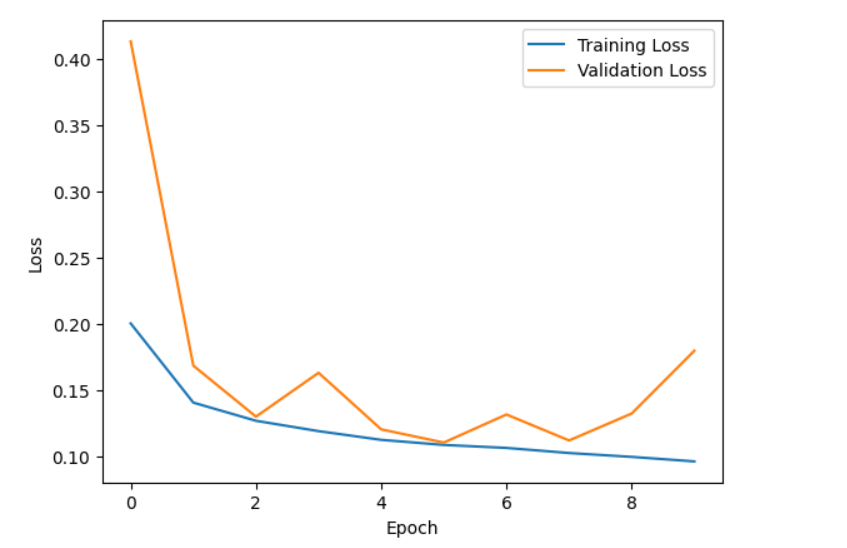

In [ ]:
plt.plot(history.history['dice_coefficient'], label='Training Dice Coefficient')
plt.plot(history.history['val_dice_coefficient'], label='Validation Dice Coefficient')
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.legend()
plt.show()

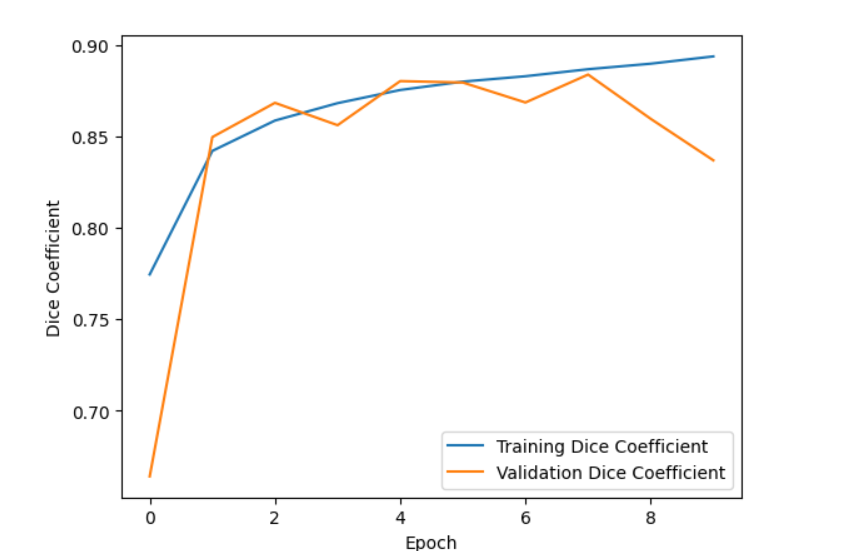

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

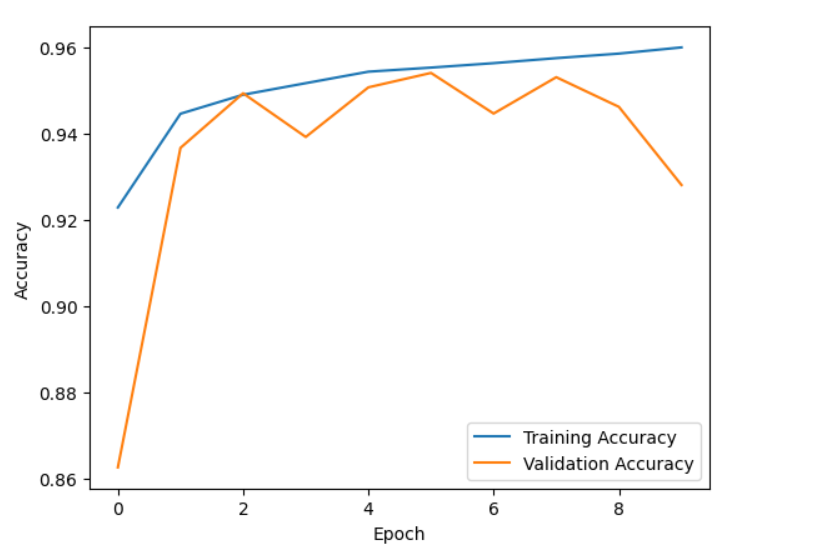


In [ ]:
loss, accuracy, precision, recall, dice_coefficient = model.evaluate(test_set)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test Dice Coefficient: {dice_coefficient:.4f}")

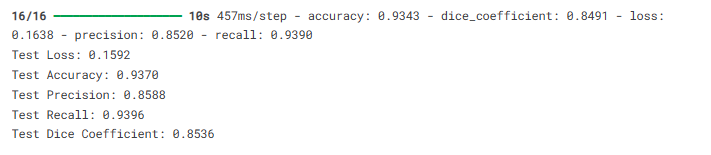

In [ ]:
print(f"{'Test Loss:':<25}{loss:.4f}")
print(f"{'Test Accuracy:':<25}{accuracy:.4f}")
print(f"{'Test Precision:':<25}{precision:.4f}")
print(f"{'Test Recall:':<25}{recall:.4f}")
print(f"{'Test Dice Coefficient:':<25}{dice_coefficient:.4f}")

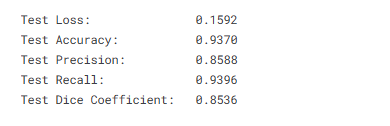

In [ ]:
n_imgs = 10
test_imgs, test_masks = next(iter(test_set))
# Use our trained model for predictions instead of the loaded_model
y_pred = model.predict(test_imgs[:n_imgs], verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(10, 128, 128, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
def display_predictions(n, test_imgs, test_masks, y_pred):
    fig, axs = plt.subplots(3, n, figsize=(20, 8))
    for i in range(n):
        dice = dice_coefficient(test_masks[i], y_pred[i])

        axs[0, i].imshow(test_imgs[i])
        axs[0, i].set_title('Image')
        axs[0, i].axis('off')

        axs[1, i].imshow(test_masks[i])
        axs[1, i].set_title('Actual Mask')
        axs[1, i].axis('off')

        axs[2, i].imshow(y_pred[i])
        axs[2, i].set_title(f'Predicted Mask\nDice: {dice:.4f}')
        axs[2, i].axis('off')

plt.show()

In [ ]:
# In Cell 47 (last cell), modify display_predictions:

def display_predictions(n, test_imgs, test_masks, y_pred):

    # Define the Dice coefficient function locally within display_predictions
    def dice_coefficient(y_true, y_pred, smooth=1):
        y_true_f = K.flatten(y_true)
        y_pred_f = K.flatten(y_pred)
        intersection = K.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


    fig, axs = plt.subplots(3, n, figsize=(20, 8))
    for i in range(n):
        # Now call the locally defined dice_coefficient function:
        dice = dice_coefficient(test_masks[i], y_pred[i])

        axs[0, i].imshow(test_imgs[i])
        axs[0, i].set_title('Image')
        axs[0, i].axis('off')

        axs[1, i].imshow(test_masks[i])
        axs[1, i].set_title('Actual Mask')
        axs[1, i].axis('off')

        axs[2, i].imshow(y_pred[i])
        axs[2, i].set_title(f'Predicted Mask\nDice: {dice:.4f}')
        axs[2, i].axis('off')

plt.show()

In [ ]:
display_predictions(n=n_imgs,
                    test_imgs=test_imgs[:n_imgs],
                    test_masks=test_masks[:n_imgs],
                    y_pred=y_pred)

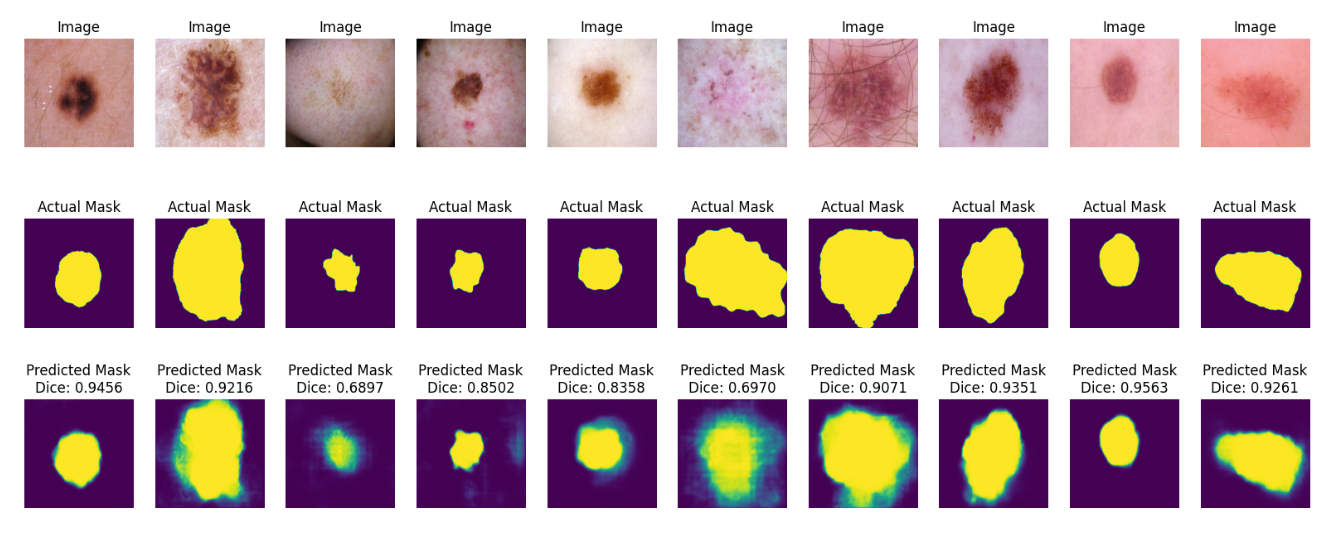